<a href="https://colab.research.google.com/github/pankhudi-priyal/ai-vs-human-text-detection/blob/main/1_logistic-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive/')

In [4]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/AI_Human.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:", df.columns.tolist())
print("\nLabel counts:")
print(df['generated'].value_counts())

Shape: (487235, 2)

First 5 rows:
                                                text  generated
0  Cars. Cars have been around since they became ...        0.0
1  Transportation is a large necessity in most co...        0.0
2  "America's love affair with it's vehicles seem...        0.0
3  How often do you ride in a car? Do you drive a...        0.0
4  Cars are a wonderful thing. They are perhaps o...        0.0

Column names: ['text', 'generated']

Label counts:
generated
0.0    305797
1.0    181438
Name: count, dtype: int64


Training samples: 40000
Testing samples:  10000

Training Logistic Regression...
Training complete!
Classification Report:
              precision    recall  f1-score   support

       Human       0.98      0.99      0.99      6327
          AI       0.99      0.97      0.98      3673

    accuracy                           0.99     10000
   macro avg       0.99      0.98      0.98     10000
weighted avg       0.99      0.99      0.99     10000



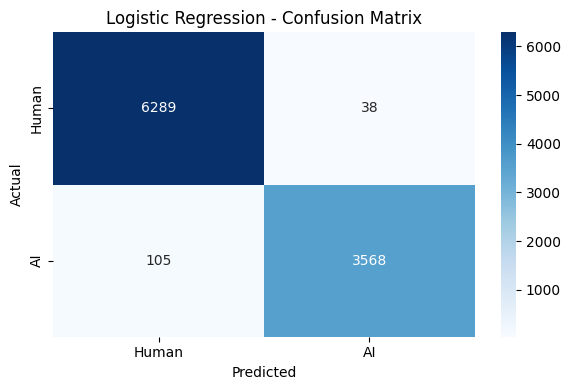

Done!


In [7]:
# ============================================
# LOGISTIC REGRESSION WITH TF-IDF
# ============================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df_sample = df.sample(n=50000, random_state=42)

X = df_sample['text']
y = df_sample['generated']

#Split into Train and Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

#Convert Text to TF-IDF Features
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

#Train the Model
print("\nTraining Logistic Regression...")
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
print("Training complete!")

#Evaluate
y_pred = model.predict(X_test_tfidf)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Human', 'AI']))

#Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human', 'AI'],
            yticklabels=['Human', 'AI'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png')
plt.show()
print("Done!")